# Exp W — Estrutura do Denominador da Razão Espectral

**Motivação (Nota 31, revisão):** a lei de escala $\mathcal{R}(f_p) \approx T_{\max}/(2\sqrt{p})$
prevê inclinação $-0.5$ em $\log_{10}\mathcal{R}$ vs $\log_{10}p$.
O Exp U mediu inclinação empírica $-1.34$ — discrepância de quase fator 3 no expoente.

Como o numerador $|\mathcal{F}[R_{\text{primo}}](f_p)| \approx T_{\max}/(2\sqrt{p})$
está correto (inclinação $-0.5$ esperada e verificável), o erro está no denominador
$|\mathcal{F}[R_{\text{comp}}](f_p)|$.

A Nota 31 estima o denominador como $O(N/T_{\max})$ — constante em $p$.
Se o expoente empírico da razão é $-1.34$ e o do numerador é $-0.5$,
o denominador deve crescer como $p^{0.84}$, não $p^0$.

**Duas perguntas:**

**W-A:** O denominador $|\mathcal{F}[R_{\text{comp}}](f_p)|$ cresce como $p^{0.84}$?
Medir diretamente em função de $p$ com $N$ e $T_{\max}$ fixos.

**W-B:** O denominador depende de $N$? Medir para um primo fixo
enquanto $N$ varia — separar o efeito local (compostos próximos de $f_p$)
do efeito global (tamanho total do sinal).

Os dois experimentos juntos dão os expoentes corretos para reescrever a Seção 2.2 da Nota 31.

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from sympy import isprime
from scipy.stats import pearsonr
from numpy.linalg import lstsq

plt.style.use('dark_background')
C_PRIME = '#00FFB2'
C_COMP  = '#FF4466'
C_RATIO = '#BB44FF'
C_FIT   = '#FFB300'
BG      = '#0D0D1A'

def S_m(t, m):
    return -np.cos(t * math.log(m)) / math.sqrt(m)

def f_m(m):
    return math.log(m) / (2 * math.pi)

def amp_em(F, freqs, m, w=5):
    """Amplitude máxima de F numa janela de w bins em torno de f_m."""
    idx = np.argmin(np.abs(freqs - f_m(m)))
    lo, hi = max(0, idx - w), min(len(F), idx + w)
    return np.max(F[lo:hi])

def construir_espectros(N, T_MAX, DT=0.05):
    """Constrói R_primo e R_comp e retorna FFTs."""
    t     = np.arange(0.1, T_MAX, DT)
    freqs = np.fft.rfftfreq(len(t), d=DT)
    primos    = [m for m in range(2, N + 1) if isprime(m)]
    compostos = [m for m in range(2, N + 1) if not isprime(m)]
    Rp = sum(S_m(t, p) for p in primos)
    Rc = sum(S_m(t, c) for c in compostos)
    Fp = np.abs(np.fft.rfft(Rp)) * DT
    Fc = np.abs(np.fft.rfft(Rc)) * DT
    return freqs, Fp, Fc, primos, compostos

print('Pronto.')

Pronto.


## W-A — Denominador vs $p$: qual é o expoente?

Com $N$ e $T_{\max}$ fixos, medir para cada primo $p \leq N$:
- Numerador: $|\mathcal{F}[R_{\text{primo}}](f_p)|$
- Denominador: $|\mathcal{F}[R_{\text{comp}}](f_p)|$
- Razão: $\mathcal{R}(f_p)$

Plotar os três em log-log vs $p$ e ajustar inclinações.
A previsão da Nota 31: numerador $\sim p^{-0.5}$, denominador $\sim p^0$, razão $\sim p^{-0.5}$.
A previsão empírica do Exp U: razão $\sim p^{-1.34}$, logo denominador $\sim p^{+0.84}$.

In [2]:
N_A    = 200
T_A    = 1500

print(f'Construindo espectros (N={N_A}, T_max={T_A})...')
freqs_a, Fp_a, Fc_a, primos_a, _ = construir_espectros(N_A, T_A)
print('Pronto.')

# Medir numerador, denominador e razão para cada primo
ps_a   = []
nums_a = []
dens_a = []
rats_a = []

print(f'\n{"p":>5} {"num":>12} {"den":>12} {"razao":>12} {"log10(R)":>10}')
print('-' * 56)
for p in primos_a:
    num = amp_em(Fp_a, freqs_a, p)
    den = amp_em(Fc_a, freqs_a, p)
    rat = num / (den + 1e-12)
    ps_a.append(p)
    nums_a.append(num)
    dens_a.append(den)
    rats_a.append(rat)
    print(f'{p:>5} {num:>12.6f} {den:>12.6f} {rat:>12.4f} '
          f'{math.log10(rat) if rat > 0 else -99:>10.4f}')

Construindo espectros (N=200, T_max=1500)...
Pronto.

    p          num          den        razao   log10(R)
--------------------------------------------------------
    2   361.109402     2.402430     150.3101     2.1770
    3   386.608818     3.240606     119.3014     2.0766
    5   313.200069     5.332482      58.7344     1.7689
    7   188.013739     6.055976      31.0460     1.4920
   11   166.945642     2.149374      77.6717     1.8903
   13   177.193986     4.195812      42.2312     1.6256
   17   148.213911     2.592171      57.1775     1.7572
   19   166.489727     6.259825      26.5965     1.4248
   23    99.655187    13.245357       7.5238     0.8764
   29   130.414486    10.482436      12.4412     1.0949
   31   122.226958    16.457183       7.4270     0.8708
   37   122.799431    22.052372       5.5685     0.7457
   41    76.023350    95.112728       0.7993    -0.0973
   43   111.931074    33.333314       3.3579     0.5261
   47   107.377300   113.445645       0.9465    -

Ajuste log-log (inclinação esperada entre parênteses):
  Numerador  |F[R_primo](f_p)|: slope = -0.4552  (esperado -0.50)  corr=-0.9689
  Denominador|F[R_comp ](f_p)|: slope = +0.8830  (esperado  0.00)  corr=0.8638
  Razão      R(f_p):            slope = -1.3382  (esperado -0.50)  corr=-0.9252

  Expoente empírico do denominador: +0.8830
  Diferença num - den (deve = slope_rat): -1.3382 vs -1.3382


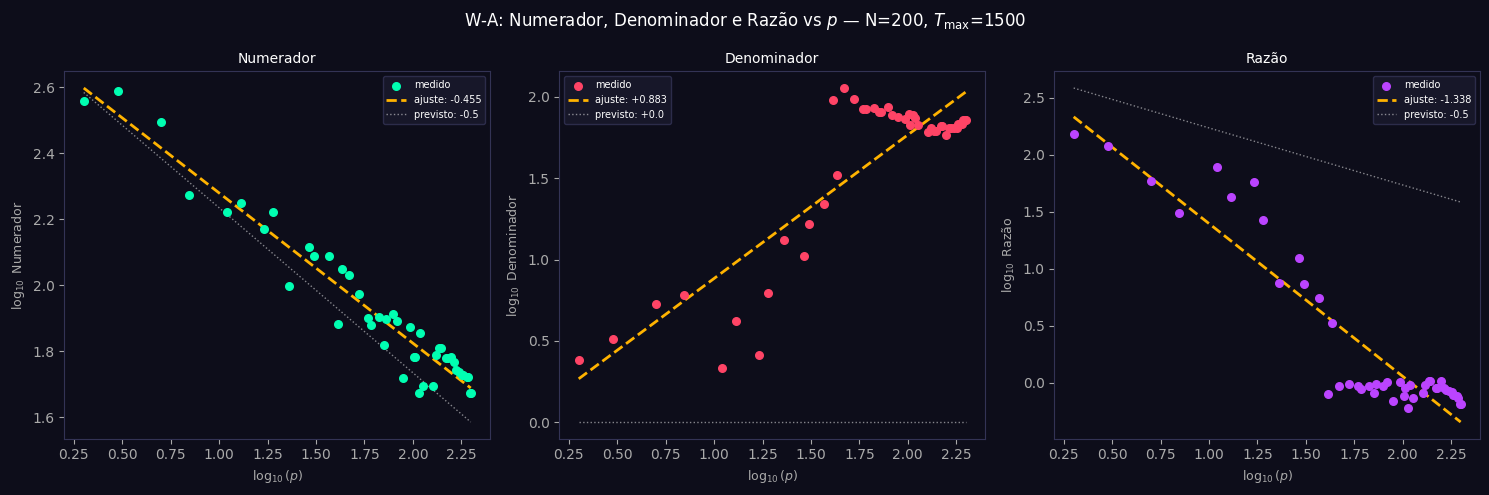

In [3]:
# Ajuste log-log para cada série
log_ps   = np.log10(ps_a)
log_nums = np.log10(nums_a)
log_dens = np.log10(dens_a)
log_rats = np.log10([r for r in rats_a])

slope_num, ic_num = np.polyfit(log_ps, log_nums, 1)
slope_den, ic_den = np.polyfit(log_ps, log_dens, 1)
slope_rat, ic_rat = np.polyfit(log_ps, log_rats, 1)

corr_num, _ = pearsonr(log_ps, log_nums)
corr_den, _ = pearsonr(log_ps, log_dens)
corr_rat, _ = pearsonr(log_ps, log_rats)

print('Ajuste log-log (inclinação esperada entre parênteses):')
print(f'  Numerador  |F[R_primo](f_p)|: slope = {slope_num:+.4f}  (esperado -0.50)  corr={corr_num:.4f}')
print(f'  Denominador|F[R_comp ](f_p)|: slope = {slope_den:+.4f}  (esperado  0.00)  corr={corr_den:.4f}')
print(f'  Razão      R(f_p):            slope = {slope_rat:+.4f}  (esperado -0.50)  corr={corr_rat:.4f}')
print()
print(f'  Expoente empírico do denominador: {slope_den:+.4f}')
print(f'  Diferença num - den (deve = slope_rat): {slope_num - slope_den:.4f} vs {slope_rat:.4f}')

# Figura
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(BG)
fig.suptitle(rf'W-A: Numerador, Denominador e Razão vs $p$ — N={N_A}, $T_{{\max}}$={T_A}',
             color='white', fontsize=12)

x_line = np.linspace(log_ps.min(), log_ps.max(), 100)

datasets = [
    (log_nums, nums_a, slope_num, ic_num, C_PRIME,
     r'$|\mathcal{F}[R_{\text{primo}}](f_p)|$', 'Numerador', -0.5),
    (log_dens, dens_a, slope_den, ic_den, C_COMP,
     r'$|\mathcal{F}[R_{\text{comp}}](f_p)|$',  'Denominador', 0.0),
    (log_rats, rats_a, slope_rat, ic_rat, C_RATIO,
     r'$\mathcal{R}(f_p)$', 'Razão', -0.5),
]

for ax, (logy, y_raw, slope, ic, color, ylabel, title, exp_slope) in zip(axes, datasets):
    ax.set_facecolor(BG)
    ax.scatter(log_ps, logy, color=color, s=30, zorder=5, label='medido')
    ax.plot(x_line, slope * x_line + ic, color=C_FIT, lw=2, ls='--',
            label=f'ajuste: {slope:+.3f}')
    ax.plot(x_line, exp_slope * x_line + ic, color='white', lw=1, ls=':',
            alpha=0.5, label=f'previsto: {exp_slope:+.1f}')
    ax.set_xlabel(r'$\log_{10}(p)$', color='#AAAAAA', fontsize=9)
    ax.set_ylabel(rf'$\log_{{10}}$ {title}', color='#AAAAAA', fontsize=9)
    ax.set_title(title, color='white', fontsize=10)
    ax.legend(fontsize=7, facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white')
    ax.tick_params(colors='#AAAAAA')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

plt.tight_layout()
plt.show()

## W-B — Denominador vs $N$: o efeito é local ou global?

Com $T_{\max}$ fixo e $p$ fixo, medir $|\mathcal{F}[R_{\text{comp}}](f_p)|$
enquanto $N$ varia.

Se o denominador cresce com $N$ (além de $p$), a estimativa $O(N/T_{\max})$
da Nota 31 estava no caminho certo mas incompleta.
Se o denominador satura rapidamente — estabiliza depois que $N$ ultrapassa $p$
por uma margem — então o efeito é *local*: são os compostos próximos de $p$
que dominam, não a soma global.

Testar com três primos representativos: pequeno (p=7), médio (p=23), grande (p=97).

In [4]:
T_B      = 1500
primos_b = [7, 23, 97]
# N varia de p+5 até 500, em passos irregulares para capturar a transição inicial
Ns_b = [12, 20, 30, 50, 75, 100, 150, 200, 300, 500]

resultados_b = {p: {'Ns': [], 'dens': [], 'nums': []} for p in primos_b}

for N in Ns_b:
    print(f'N={N}...', end=' ', flush=True)
    freqs_b, Fp_b, Fc_b, _, _ = construir_espectros(N, T_B)
    for p in primos_b:
        if p > N:
            continue
        num = amp_em(Fp_b, freqs_b, p)
        den = amp_em(Fc_b, freqs_b, p)
        resultados_b[p]['Ns'].append(N)
        resultados_b[p]['nums'].append(num)
        resultados_b[p]['dens'].append(den)

print('\nPronto.')

# Tabela
for p in primos_b:
    print(f'\np={p}:')
    print(f'  {"N":>5} {"num":>12} {"den":>12} {"den/num":>10}')
    print('  ' + '-'*44)
    for N, num, den in zip(resultados_b[p]['Ns'],
                           resultados_b[p]['nums'],
                           resultados_b[p]['dens']):
        print(f'  {N:>5} {num:>12.6f} {den:>12.6f} {den/num:>10.4f}')

N=12... N=20... N=30... N=50... N=75... N=100... N=150... N=200... N=300... N=500... 
Pronto.

p=7:
      N          num          den    den/num
  --------------------------------------------
     12   189.131146     3.823097     0.0202
     20   188.702160     4.114274     0.0218
     30   188.533840     4.403327     0.0234
     50   188.403612     4.906083     0.0260
     75   188.252173     5.273139     0.0280
    100   188.216766     5.464644     0.0290
    150   188.074032     5.772690     0.0307
    200   188.013739     6.055976     0.0322
    300   187.932737     6.452995     0.0343
    500   187.807823     7.044035     0.0375

p=23:
      N          num          den    den/num
  --------------------------------------------
     30   100.972429     7.290972     0.0722
     50   100.386100    10.039797     0.1000
     75    99.960000    11.108690     0.1111
    100    99.875153    11.687137     0.1170
    150    99.563781    12.569984     0.1263
    200    99.655187    13.245357 

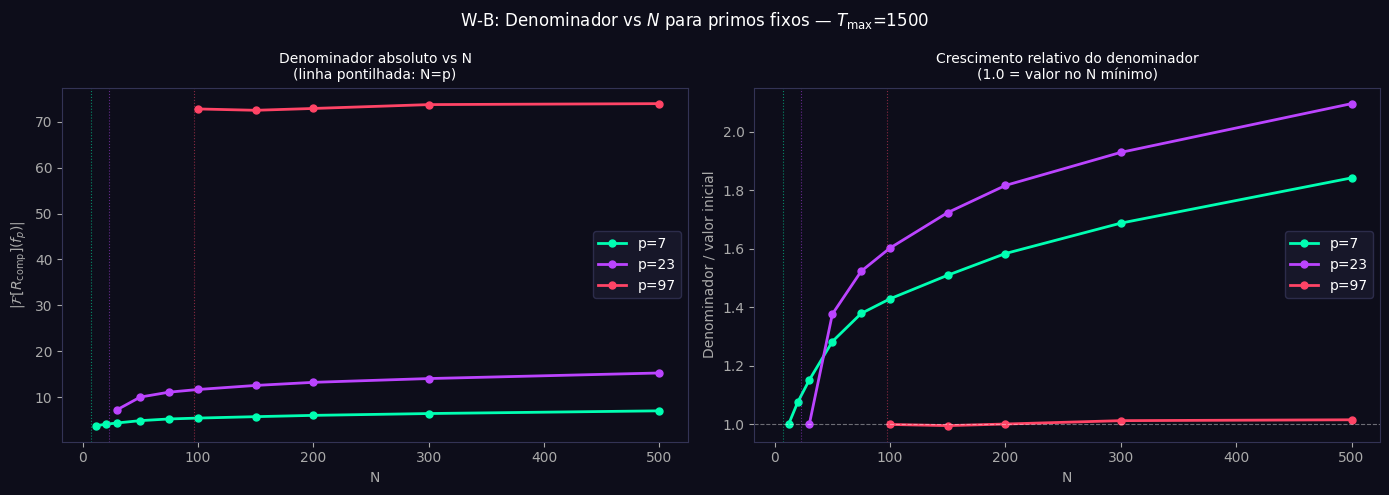

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)
fig.suptitle(rf'W-B: Denominador vs $N$ para primos fixos — $T_{{\max}}$={T_B}',
             color='white', fontsize=12)

colors_p = [C_PRIME, C_RATIO, C_COMP]

# Painel 1: denominador absoluto vs N
ax = axes[0]
ax.set_facecolor(BG)
for p, color in zip(primos_b, colors_p):
    Ns_  = resultados_b[p]['Ns']
    dens = resultados_b[p]['dens']
    ax.plot(Ns_, dens, color=color, lw=2, marker='o', ms=5, label=f'p={p}')
    # linha vertical em N=p para marcar quando p entra no sinal
    ax.axvline(p, color=color, lw=0.8, ls=':', alpha=0.5)
ax.set_xlabel('N', color='#AAAAAA')
ax.set_ylabel(r'$|\mathcal{F}[R_{\text{comp}}](f_p)|$', color='#AAAAAA')
ax.set_title('Denominador absoluto vs N\n(linha pontilhada: N=p)', color='white', fontsize=10)
ax.legend(facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white')
ax.tick_params(colors='#AAAAAA')
for spine in ax.spines.values():
    spine.set_edgecolor('#333355')

# Painel 2: denominador normalizado pelo valor em N=p+margem (N mínimo disponível)
# para ver crescimento relativo depois que p já está no sinal
ax = axes[1]
ax.set_facecolor(BG)
for p, color in zip(primos_b, colors_p):
    Ns_  = np.array(resultados_b[p]['Ns'])
    dens = np.array(resultados_b[p]['dens'])
    # normalizar pelo primeiro valor disponível
    dens_norm = dens / dens[0]
    ax.plot(Ns_, dens_norm, color=color, lw=2, marker='o', ms=5, label=f'p={p}')
    ax.axvline(p, color=color, lw=0.8, ls=':', alpha=0.5)
ax.axhline(1.0, color='white', lw=0.8, ls='--', alpha=0.4)
ax.set_xlabel('N', color='#AAAAAA')
ax.set_ylabel('Denominador / valor inicial', color='#AAAAAA')
ax.set_title('Crescimento relativo do denominador\n(1.0 = valor no N mínimo)', color='white', fontsize=10)
ax.legend(facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white')
ax.tick_params(colors='#AAAAAA')
for spine in ax.spines.values():
    spine.set_edgecolor('#333355')

plt.tight_layout()
plt.show()

## W-C — Contribuição por distância logarítmica

Se a Nota 31 erra porque ignora o peso $1/|\log c - \log p|$,
então os compostos *mais próximos* de $f_p$ devem dominar o denominador.

Para um primo fixo $p$, medir quanto cada composto $c \leq N$ contribui
individualmente para $|\mathcal{F}[R_{\text{comp}}](f_p)|$,
e correlacionar essa contribuição com $|\log c - \log p|$.

Se a contribuição decai como $1/|\log c - \log p|$, a soma diverge
logaritmicamente perto de $p$ — exatamente o que produziria um expoente
diferente de zero no denominador.

p=7: slope log-log contrib vs dist = -1.8241 (esperado -1.0 se decai como 1/dist)  corr=-0.7390
p=23: slope log-log contrib vs dist = -1.5366 (esperado -1.0 se decai como 1/dist)  corr=-0.7693
p=97: slope log-log contrib vs dist = -1.0434 (esperado -1.0 se decai como 1/dist)  corr=-0.6855


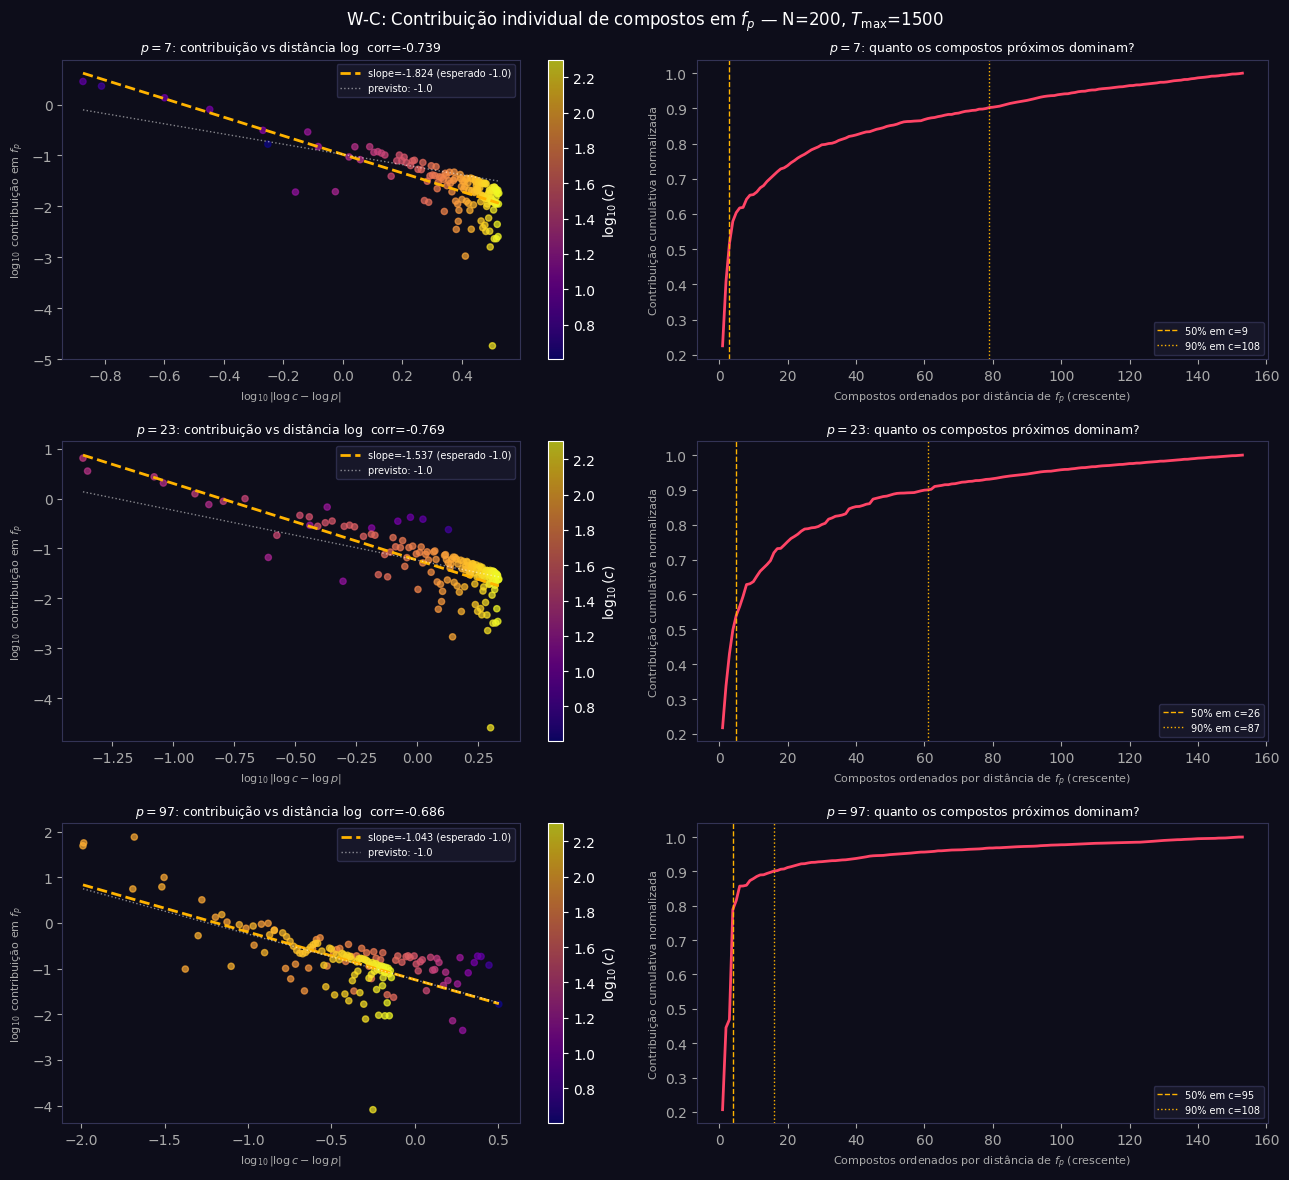

In [6]:
T_C = 1500
DT  = 0.05
N_C = 200
t_c = np.arange(0.1, T_C, DT)
freqs_c = np.fft.rfftfreq(len(t_c), d=DT)

# Para cada primo de teste, medir a contribuição individual de cada composto
primos_c  = [p for p in range(2, N_C + 1) if isprime(p)]
compostos_c = [c for c in range(2, N_C + 1) if not isprime(c)]

# Escolher três primos de teste
primos_teste = [7, 23, 97]

fig, axes = plt.subplots(len(primos_teste), 2,
                          figsize=(13, 4 * len(primos_teste)))
fig.patch.set_facecolor(BG)
fig.suptitle(rf'W-C: Contribuição individual de compostos em $f_p$ — N={N_C}, $T_{{\max}}$={T_C}',
             color='white', fontsize=12)

for row, p_test in enumerate(primos_teste):
    f_p = f_m(p_test)
    idx_p = np.argmin(np.abs(freqs_c - f_p))

    contrib = []
    dist_log = []
    for c in compostos_c:
        Sc = S_m(t_c, c)
        Fc_ind = np.abs(np.fft.rfft(Sc)) * DT
        lo = max(0, idx_p - 5)
        hi = min(len(Fc_ind), idx_p + 5)
        amp = np.max(Fc_ind[lo:hi])
        dist = abs(math.log(c) - math.log(p_test))
        contrib.append(amp)
        dist_log.append(dist)

    contrib   = np.array(contrib)
    dist_log  = np.array(dist_log)
    log_dist  = np.log10(dist_log + 1e-12)
    log_contr = np.log10(contrib + 1e-12)

    # Ajuste log-log: contrib ~ dist^slope
    slope_c, ic_c = np.polyfit(log_dist, log_contr, 1)
    corr_c, _     = pearsonr(log_dist, log_contr)

    # Painel esquerdo: contribuição vs distância log (scatter + ajuste)
    ax = axes[row][0]
    ax.set_facecolor(BG)
    sc = ax.scatter(log_dist, log_contr,
                    c=np.log10(np.array(compostos_c)), cmap='plasma',
                    s=20, alpha=0.7)
    plt.colorbar(sc, ax=ax, label=r'$\log_{10}(c)$')
    x_fit = np.linspace(log_dist.min(), log_dist.max(), 100)
    ax.plot(x_fit, slope_c * x_fit + ic_c, color=C_FIT, lw=2, ls='--',
            label=f'slope={slope_c:.3f} (esperado -1.0)')
    ax.plot(x_fit, -1.0 * x_fit + ic_c, color='white', lw=1, ls=':',
            alpha=0.5, label='previsto: -1.0')
    ax.set_xlabel(r'$\log_{10}|\log c - \log p|$', color='#AAAAAA', fontsize=8)
    ax.set_ylabel(r'$\log_{10}$ contribuição em $f_p$', color='#AAAAAA', fontsize=8)
    ax.set_title(rf'$p={p_test}$: contribuição vs distância log  corr={corr_c:.3f}',
                 color='white', fontsize=9)
    ax.legend(fontsize=7, facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white')
    ax.tick_params(colors='#AAAAAA')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

    # Painel direito: contribuição cumulativa ordenada por distância crescente
    # (mostra quanto os compostos próximos dominam)
    ax = axes[row][1]
    ax.set_facecolor(BG)
    ordem = np.argsort(dist_log)
    cum = np.cumsum(contrib[ordem])
    cum_norm = cum / cum[-1]
    n_compostos = np.arange(1, len(cum) + 1)
    ax.plot(n_compostos, cum_norm, color=C_COMP, lw=2)
    # marcar o ponto em que 50% e 90% da contribuição já foi acumulada
    for frac, ls_ in [(0.5, '--'), (0.9, ':')]:
        idx_f = np.searchsorted(cum_norm, frac)
        if idx_f < len(n_compostos):
            ax.axvline(n_compostos[idx_f], color=C_FIT, lw=1, ls=ls_,
                       label=f'{int(frac*100)}% em c={compostos_c[ordem[idx_f]]}')
    ax.set_xlabel('Compostos ordenados por distância de $f_p$ (crescente)',
                  color='#AAAAAA', fontsize=8)
    ax.set_ylabel('Contribuição cumulativa normalizada', color='#AAAAAA', fontsize=8)
    ax.set_title(rf'$p={p_test}$: quanto os compostos próximos dominam?',
                 color='white', fontsize=9)
    ax.legend(fontsize=7, facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white')
    ax.tick_params(colors='#AAAAAA')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

    print(f'p={p_test}: slope log-log contrib vs dist = {slope_c:.4f} '
          f'(esperado -1.0 se decai como 1/dist)  corr={corr_c:.4f}')

plt.tight_layout()
plt.show()

## Interpretação

**W-A** responde: qual é o expoente real do denominador em função de $p$?
- Se `slope_den ≈ 0`: a Nota 31 estava certa no expoente, errou apenas no prefator.
- Se `slope_den ≈ +0.84`: o denominador cresce como $p^{0.84}$ e a derivação
  precisa incorporar os compostos próximos de $f_p$ com peso $1/|\log c - \log p|$.
- A consistência `slope_num - slope_den ≈ slope_rat` é a verificação interna.

**W-B** responde: o denominador satura com $N$ ou continua crescendo?
- Se o denominador estabiliza logo depois de $N > p$: o efeito é local —
  são os compostos próximos de $p$ que dominam, e o $N$ da Nota 31 é irrelevante.
- Se continua crescendo linearmente com $N$: o efeito é global e $O(N/T_{\max})$
  era a estrutura certa, só com prefator errado.

**W-C** responde: o decaimento da contribuição individual com a distância
logarítmica é realmente $\sim 1/|\log c - \log p|$?
- `slope ≈ -1`: sim — a Nota 31 precisa incorporar essa soma ponderada.
- `slope ≠ -1`: outro mecanismo domina.
- O painel cumulativo mostra concretamente se 50% ou 90% da contribuição
  vem de poucos compostos próximos — o que determinaria se uma aproximação
  local (apenas compostos dentro de $[p/2, 2p]$, por exemplo) seria suficiente.

Os três resultados juntos fornecem os insumos empíricos para reescrever
a Seção 2.2 da Nota 31 com a estimativa correta do denominador.

---
*Exp W — T. Bandeira, 2026*